<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_3/cryptography.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import aux
importlib.reload(aux)
from aux import char_to_int, int_to_char, clean_text_with_spaces, get_bigram_matrix_27, transition_b1_double, transition_b2_triple

import samplers
importlib.reload(samplers)
from samplers import metropolis_hastings_log, composite_transition

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import random

/content/MCMC-MonteCarlo-TFG
Already up to date.
/content


In [24]:
# Subimos un texto en español para entrenar nuestra matriz
print("Por favor, sube un archivo .txt con solo texto en español para entrenar la matriz de bigramas:")
uploaded = files.upload()

# Leemos y limpiamos el archivo subido
name = list(uploaded.keys())[0]
try:
    reference = uploaded[name].decode('utf-8')
except UnicodeDecodeError:
    reference = uploaded[name].decode('latin-1')
reference = clean_text_with_spaces(reference)

# Creamos la matriz de probabilidades de transición entre bigramas
size = 27
M_esp = get_bigram_matrix_27(reference, size)
epsilon = 1e-10
M_log_esp = np.log(M_esp + epsilon)

Por favor, sube un archivo .txt con solo texto en español para entrenar la matriz de bigramas:


Saving thoens.txt to thoens (1).txt


In [25]:
rng = np.random.default_rng(seed = 1)

# Definimos el mensaje original que queremos cifrar (en español y de una extensión adecuada)
original = clean_text_with_spaces("El texto recuperado en el estado de mínima energía coincide plenamente con el mensaje original, demostrando que el muestreo de Cadenas de Markov es una herramienta excepcionalmente robusta no solo para la integración numérica o la simulación física, sino también para la resolución de problemas combinatorios complejos de optimización estocástica.")

# Generamos la clave
indices = list(range(size))
key = np.array(indices)
rng.shuffle(key)

# Creamos el diccionario para cifrar el mensaje
# dictionary[char_to_int(letra_real)] = indice_cifrado
dictionary = {key[i]: i for i in range(size)}

# Ciframos el mensaje original
secret = [dictionary[char_to_int(c)] for c in original]

# Matriz de observaciones del texto cifrado
O_matrix = np.zeros((size, size))
for i in range(len(secret) - 1):
    O_matrix[secret[i], secret[i+1]] += 1

In [26]:
# Generamos la propuesta usando la composición de trancisiones

# Agrupamos las funciones base
base_transitions = [transition_b1_double, transition_b2_triple]

# Definimos el vector de probabilidades
alphas = [0.80, 0.20]

# Fabricamos la transición compuesta
proposal_sampler = composite_transition(base_transitions, alphas)

In [27]:
initial = rng.permutation(size) # Estado inicial aleatorio

# Definimos la energía del problema
def log_target_pdf(current_state):
        return np.sum(O_matrix * M_log_esp[np.ix_(current_state, current_state)])

# Asumimos simetría (Metropolis estándar) devolviendo 0.0.
# Aunque el salto triple introduce asimetría, la ignoramos porque el objetivo
# es la optimización (descifrado) y no el muestreo estricto.
def log_proposal_pdf(proposed_state, current_state):
    return 0.0
def log_proposal_pdf(proposed_state, current_state):
    return 0.0

iterations=15000 # Número de iteraciones

# Ejecutamos el algoritmo de Metropolis Hastings
best_state, historial = metropolis_hastings_log(initial, log_target_pdf, proposal_sampler, log_proposal_pdf, iterations)

Texto cifrado:
QKE QD VEIQLFCQITPVEQYEQKEQW TPVEPQENSYSNTEQYQIZSTELVSYLSPQECKQYTNQY QELVYEQKENQYWTUQEVISZSYTKEPQNVW ITYPVEGFQEQKENFQW IQVEPQELTPQYTWEPQENTIOVMEQWEFYTEBQIITNSQY TEQDLQCLSVYTKNQY QEIVAFW TEYVEWVKVECTITEKTESY QZITLSVYEYFNQISLTEVEKTEWSNFKTLSVYERSWSLTEWSYVE TNASQYECTITEKTEIQWVKFLSVYEPQECIVAKQNTWELVNASYT VISVWELVNCKQUVWEPQEVC SNSHTLSVYEQW VLTW SLT


Texto recuperado:
EL TEXTO RECUPERADO EN EL ESTADO DE MINIMA ENERGIA COINCIDE PLENAMENTE CON EL MENSAJE ORIGINAL DEMOSTRANDO QUE EL MUESTREO DE CADENAS DE MARFOY ES UNA VERRAMIENTA EXCEPCIONALMENTE ROBUSTA NO SOLO PARA LA INTEGRACION NUMERICA O LA SIMULACION HISICA SINO TAMBIEN PARA LA RESOLUCION DE PROBLEMAS COMBINATORIOS COMPLEJOS DE OPTIMIZACION ESTOCASTICA




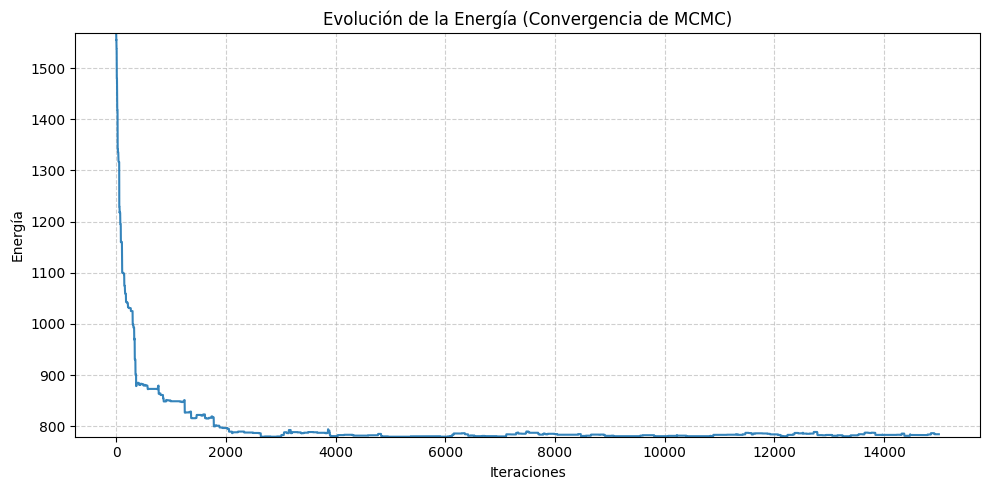

In [28]:
# Mostramos resultados

print("Texto cifrado:")
initial_text = "".join([int_to_char(num) for num in secret])
print(initial_text)
print("\n")

print("Texto recuperado:")
final_text = "".join([int_to_char(best_state[num]) for num in secret])
print(final_text)
print("\n")

# Graficamos el historial de la energía
plt.figure(figsize=(10, 5))
plt.plot(-np.array(historial), color='#1f77b4', linewidth=1.5, alpha=0.9)

plt.title('Evolución de la Energía (Convergencia de MCMC)')
plt.xlabel('Iteraciones')
plt.ylabel('Energía')
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(min(-np.array(historial)), max(-np.array(historial)))
plt.savefig("CRIPTOGRAFIA.pdf")
plt.tight_layout()
plt.show()


In [29]:
from google.colab import files
files.download("CRIPTOGRAFIA.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>